# Getting Started:
The game environment comes equipped with agents that have already been implemented for you. To see a list of these default agents, run:


In [4]:
!pip install kaggle-environments

Defaulting to user installation because normal site-packages is not writeable
  Using cached kaggle_environments-1.30.1-py3-none-any.whl.metadata (829 bytes)
  Using cached gymnax-0.0.8-py3-none-any.whl.metadata (19 kB)
  Using cached litellm-1.90.0-py3-none-any.whl.metadata (40 kB)
  Using cached transformers-5.12.1-py3-none-any.whl.metadata (33 kB)
Using cached kaggle_environments-1.30.1-py3-none-any.whl (13.6 MB)
Using cached gymnax-0.0.8-py3-none-any.whl (96 kB)
Using cached litellm-1.90.0-py3-none-any.whl (16.6 MB)
Using cached transformers-5.12.1-py3-none-any.whl (11.2 MB)

   ---------------------------------------- 0/4 [transformers]
   ---------------------------------------- 0/4 [transformers]
   ---------------------------------------- 0/4 [transformers]
   ---------------------------------------- 0/4 [transformers]
   ---------------------------------------- 0/4 [transformers]
   ---------------------------------------- 0/4 [transformers]
   --------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
crewai 0.177.0 requires litellm==1.74.9, but you have litellm 1.90.0 which is incompatible.
stagehand 0.5.2 requires litellm<1.75.0,>=1.72.0, but you have litellm 1.90.0 which is incompatible.
stagehand 0.5.2 requires openai<1.99.6,>=1.83.0, but you have openai 2.44.0 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\ANANYAKUMAR\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
!pip install ipywidgets widgetsnbextension

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.2 MB 4.2 MB/s eta 0:00:01
   ----------------------- ---------------- 1.3/2.2 MB 3.7 MB/s eta 0:00:01
   --------------------------------- ------ 1.8/2.2 MB 3.2 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 3.3 MB/s  0:00:00
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 914.9/914.9 kB 4.6 MB/s  0:00:00

   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]




[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\ANANYAKUMAR\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: kernel kernelspec migrate run troubleshoo

In [21]:
from kaggle_environments import make, evaluate

# Create the game environment
# Set debug=True to see the errors if your agent refuses to run

env = make("connectx", debug=True)

# List of available default agents
print(list(env.agents))

['random', 'negamax']


The "random" agent selects (uniformly) at random from the set of valid moves. In Connect Four, a move is considered valid if there's still space in the column to place a disc (i.e., if the board has seven rows, the column has fewer than seven discs).

In the code cell below, this agent plays one game round against a copy of itself.

In [ ]:
# Two random agents play one game round

env.run(["random", "random"])

# Show the game

env.render(mode="ipython", width=500, height=450)

You can use the player above to view the game in detail: every move is captured and can be replayed. ***Try this now!***

As you'll soon see, this information will prove incredibly useful for brainstorming ways to improve our agents.

# Defining agents

To participate in the competition, you'll create your own agents.

Your agent should be implemented as a Python function that accepts two arguments: obs and config. It returns an integer with the selected column, where indexing starts at zero. So, the returned value is one of 0-6, inclusive.

We'll start with a few examples, to provide some context. In the code cell below:

1. The first agent behaves identically to the "random" agent

2. The second agent always selects the middle column, whether it's valid or not! Note that if any agent selects an invalid move, it loses the game.

3. The third agent selects the leftmost valid column


In [13]:
# Selects random valid columns
import random
def random_agent(observation, configuration):
    valid_moves = [col for col in range(configuration.columns) if observation.board[col] == 0]
    return random.choice(valid_moves)

def agent_middle(observation, configuration):
    # Selects the middle column if valid, otherwise selects a random valid column
    middle_col = configuration.columns // 2
    if observation.board[middle_col] == 0:
        return middle_col
    else:
        valid_moves = [col for col in range(configuration.columns) if observation.board[col] == 0]
        return random.choice(valid_moves)

def agent_left(observation, configuration):
    # Selects the leftmost valid column
    valid_moves = [col for col in range(configuration.columns) if observation.board[col] == 0]
    return valid_moves[0] if valid_moves else None

So, what are obs and config, exactly?

**obs**
obs contains two pieces of information:

<li>obs.board - the game board (a Python list with one item for each grid location)</li>
<li>obs.mark - the piece assigned to the agent (either 1 or 2)</li>
obs.board is a Python list that shows the locations of the discs, where the first row appears first, followed by the second row, and so on. We use 1 to track player 1's discs, and 2 to track player 2's discs. For instance, for this game board:

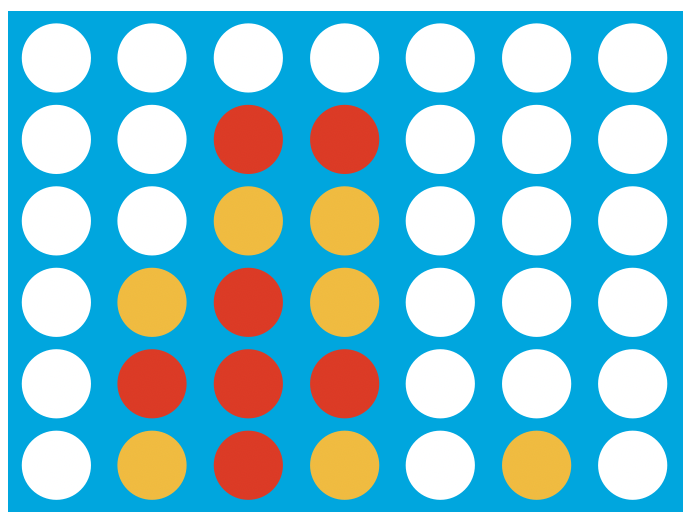

obs.board would be [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 1, 2, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 2, 1, 2, 0, 2, 0].

**config**
config contains three pieces of information:

<li>config.columns - number of columns in the game board (7 for Connect Four)</li>
<li>config.rows - number of rows in the game board (6 for Connect Four)</li>
<li>config.inarow - number of pieces a player needs to get in a row in order to win (4 for Connect Four)</li>
Take the time now to investigate the three agents we've defined above. Make sure that the code makes sense to you!

# Evaluating agents
To have the custom agents play one game round, we use the same env.run() method as before.

In [14]:
# Agents play one game round
env.run([agent_left, random_agent])

# Show the game
env.render(mode="ipython")

In [17]:
# Agents play one game round
env.run([agent_middle, random_agent])

# Show the game
env.render(mode="ipython")

The outcome of a single game is usually not enough information to figure out how well our agents are likely to perform. To get a better idea, we'll calculate the win percentages for each agent, averaged over multiple games. For fairness, each agent goes first half of the time.

To do this, we'll use the get_win_percentages() function (defined in a hidden code cell). To view the details of this function, click on the "Code" button below.

In [15]:
import numpy as np
def get_win_percentages(agent1, agent2, n_rounds=100):
    # Use default Connect FOur setup
    config = {'rows': 6, 'columns': 7, 'inarow': 4}

    # Agent 1 goes first (roughly) half the time,
    outcomes  = evaluate("connectx", [agent1, agent2], config, num_episodes=n_rounds//2)

    # Agent 2 goes first (roughly) half the time,
    outcomes += [[b,a] for [a,b] in evaluate("connectx", [agent2, agent1], config, [], num_episodes=n_rounds//2)]

    print(f"Agent 1 win percentage: {np.round(outcomes.count([1,-1])/len(outcomes),2)}")
    print(f"Agent 2 win percentage: {np.round(outcomes.count([-1,1])/len(outcomes),2)}")
    print("Number of Invalid Plays by agent 1:", outcomes.count([None,0]))
    print("Number of Invalid Plays by agent 2:", outcomes.count([0,None]))

In [16]:
get_win_percentages(agent_left, random_agent, n_rounds=100)

Agent 1 win percentage: 0.8
Agent 2 win percentage: 0.2
Number of Invalid Plays by agent 1: 0
Number of Invalid Plays by agent 2: 0


In [18]:
get_win_percentages(agent_middle, random_agent, n_rounds=100)

Agent 1 win percentage: 0.89
Agent 2 win percentage: 0.11
Number of Invalid Plays by agent 1: 0
Number of Invalid Plays by agent 2: 0
